# Huấn luyện Mô hình: Hồi quy Tuyến tính (Linear Regression)

Notebook này minh họa quá trình chia dữ liệu, chuẩn hóa (để tránh rò rỉ dữ liệu) và huấn luyện mô hình dự đoán giá bán (Final_Price) bằng các module tự code 100% từ đầu (from scratch).

In [1]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Thiết lập đường dẫn động (tương thích VS Code & Jupyter)
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.abspath(os.path.join(current_dir, '..'))
else:
    project_root = current_dir

src_path = os.path.join(project_root, 'src')
sys.path.insert(0, project_root)

# Xóa cache thư viện cũ (nếu có) để Python chịu đọc đường dẫn mới
if 'src.models' in sys.modules:
    del sys.modules['src.models']
if 'src.models.preprocessing' in sys.modules:
    del sys.modules['src.models.preprocessing']
if 'src.models.linear_regression' in sys.modules:
    del sys.modules['src.models.linear_regression']
if 'src.models.metrics' in sys.modules:
    del sys.modules['src.models.metrics']

from src.models.preprocessing import train_test_split, StandardScaler
from src.models.linear_regression import LinearRegression
from src.models.metrics import mean_absolute_error, root_mean_squared_error

print("Modules loaded successfully.")

Modules loaded successfully.


In [2]:
# Load dữ liệu đã qua Feature Engineering
data_path = os.path.join(project_root, 'data', 'processed', 'ecommerce_features.csv')
df = pd.read_csv(data_path)
print(f"Shape: {df.shape}")
df.head()

Shape: (3660, 18)


,Price (Rs.),Discount (%),Final_Price(Rs.),Purchase_Year,Purchase_Month,Purchase_Day,Purchase_DayOfWeek,Purchase_IsWeekend,Category_Books,Category_Clothing,Category_Electronics,Category_Home & Kitchen,Category_Sports,Category_Toys,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Net Banking,Payment_Method_UPI
0,36.53,15,31.05,2024,11,12,1,0,0,0,0,0,1,0,0,0,1,0
1,232.79,20,186.23,2024,2,9,4,0,0,1,0,0,0,0,0,0,1,0
2,317.02,25,237.76,2024,9,1,6,1,0,0,0,0,1,0,1,0,0,0
3,173.19,25,129.89,2024,4,1,0,0,0,0,0,0,0,1,0,0,0,1
4,244.80,20,195.84,2024,9,27,4,0,0,0,0,0,0,0,0,0,1,0


### 1. Phân chia Train / Test

In [3]:
# Xác định Features (X) và Target (y)
# Ở đây ta dự đoán Final_Price(Rs.) dựa trên Giá gốc, Giảm giá và các đặc trưng khác.
target_col = 'Final_Price(Rs.)'

X = df.drop(columns=[target_col])
y = df[target_col]

# Chia tập dữ liệu (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (2928, 17)
X_test shape: (732, 17)


### 2. Chuẩn hóa dữ liệu (Standardization)
Lưu ý: Chỉ fit trên tập Train, sau đó transform cho cả Train và Test.

In [4]:
scaler = StandardScaler()

# Chỉ chuẩn hóa các biến số liên tục (ví dụ: Price, Discount). Bỏ qua các cột One-Hot (giá trị 0,1)
numeric_cols = ['Price (Rs.)', 'Discount (%)', 'Purchase_Year', 'Purchase_Month', 'Purchase_Day']

# Tạm thời tạo bản copy để chuẩn hóa
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit và Transform trên tập Train
scaler.fit(X_train[numeric_cols])
X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])

# Transform trên tập Test (dùng mean/std của Train)
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,Price (Rs.),Discount (%),Purchase_Year,Purchase_Month,Purchase_Day,Purchase_DayOfWeek,Purchase_IsWeekend,Category_Books,Category_Clothing,Category_Electronics,Category_Home & Kitchen,Category_Sports,Category_Toys,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Net Banking,Payment_Method_UPI
1966,-0.788911,-1.265761,0.0,-1.258911,-0.656064,5,1,0,0,1,0,0,0,0,1,0,0
570,-0.862578,-0.582474,0.0,-1.584595,-1.117749,5,1,0,0,0,0,1,0,0,0,0,0
3388,1.230126,0.442456,0.0,0.695193,-1.117749,1,0,0,0,1,0,0,0,0,0,0,0
343,-1.493448,-1.265761,0.0,1.346561,-0.886906,1,0,0,1,0,0,0,0,1,0,0,0
3408,-0.480468,-0.582474,0.0,0.369509,-0.425222,4,0,0,0,0,0,1,0,0,0,0,0


### 3. Huấn luyện Mô hình Hồi quy Tuyến tính (Linear Regression)

In [5]:
model = LinearRegression()

# Train mô hình
model.fit(X_train_scaled, y_train)

print("Training completed!")
print(f"Bias (Intercept): {model.bias:.4f}")

Training completed!
Bias (Intercept): 209.8414


### 4. Đánh giá Mô hình (Evaluation)

In [6]:
# Dự đoán trên tập Test
y_pred = model.predict(X_test_scaled)

# Tính toán sai số
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Test MAE : {mae:.4f} Rs.")
print(f"Test RMSE: {rmse:.4f} Rs.")

Test MAE : 15.2589 Rs.
Test RMSE: 22.6519 Rs.


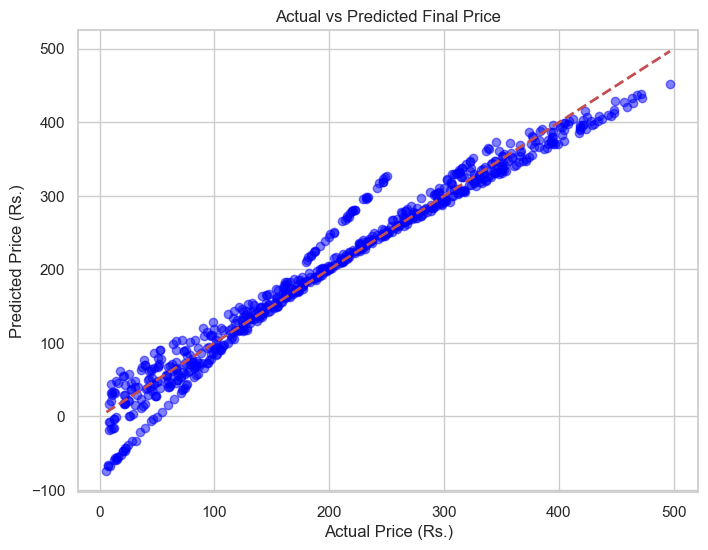

In [7]:
# Trực quan hóa giá trị Thực tế vs Dự đoán
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Final Price')
plt.xlabel('Actual Price (Rs.)')
plt.ylabel('Predicted Price (Rs.)')
plt.show()